# 05b — Xj Maps ("Urgent Area" Views)

Reads the already-computed Round 2 results (`p_median_results.csv`, P_VALUES=[2000,5000,8000])
directly -- no re-solving needed. Raw xⱼ values (not a ratio or per-capita rate): LSOAs with
xⱼ = 0 need nothing further, LSOAs with high xⱼ are the urgent areas.

Main map: Scenario C (moderate equity, α=0.3 -- the scenario the proposal already treats as
primary elsewhere) at p=5000, the middle of the three tested values. Also included: the same
map at p=2000/8000 for context, and an A-vs-D comparison.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

BASE_CANDIDATES = [
    "/Users/alexia/Documents/CASA/Dissertation",
    os.path.abspath(os.path.join(os.getcwd(), "..")),
]
BASE = next(
    (b for b in BASE_CANDIDATES
     if os.path.exists(os.path.join(b, "05_processed/p_median_results.csv"))),
    BASE_CANDIDATES[0],
)
print("Using BASE:", BASE)

results_wide = pd.read_csv(os.path.join(BASE, "05_processed/p_median_results.csv"))
results_wide["lsoa_code"] = results_wide["lsoa_code"].astype(str)

lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))
if lsoa_boundaries.crs is None:
    lsoa_boundaries = lsoa_boundaries.set_crs(epsg=27700)
elif lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)
lsoa_london = lsoa_boundaries.rename(columns={"LSOA21CD": "lsoa_code"})[["lsoa_code", "geometry"]]
lsoa_london["lsoa_code"] = lsoa_london["lsoa_code"].astype(str)
lsoa_london = lsoa_london[lsoa_london["lsoa_code"].isin(results_wide["lsoa_code"])]

figures_dir = os.path.join(BASE, "06_outputs/figures")
os.makedirs(figures_dir, exist_ok=True)

print("Loaded:", results_wide.shape, "| columns available:", [c for c in results_wide.columns if c.startswith("xj_")])


Using BASE: /Users/alexia/Documents/CASA/Dissertation
Loaded: (4994, 26) | columns available: ['xj_A_p2000', 'xj_A_p5000', 'xj_A_p8000', 'xj_B_p2000', 'xj_B_p5000', 'xj_B_p8000', 'xj_C_p2000', 'xj_C_p5000', 'xj_C_p8000', 'xj_D_p2000', 'xj_D_p5000', 'xj_D_p8000']


## Main map — Scenario C, p=5000

p=5000, Scenario C: 4,013 LSOAs need 0 new units, 981 LSOAs are allocated >0 (the 'urgent areas'), max xj = 8


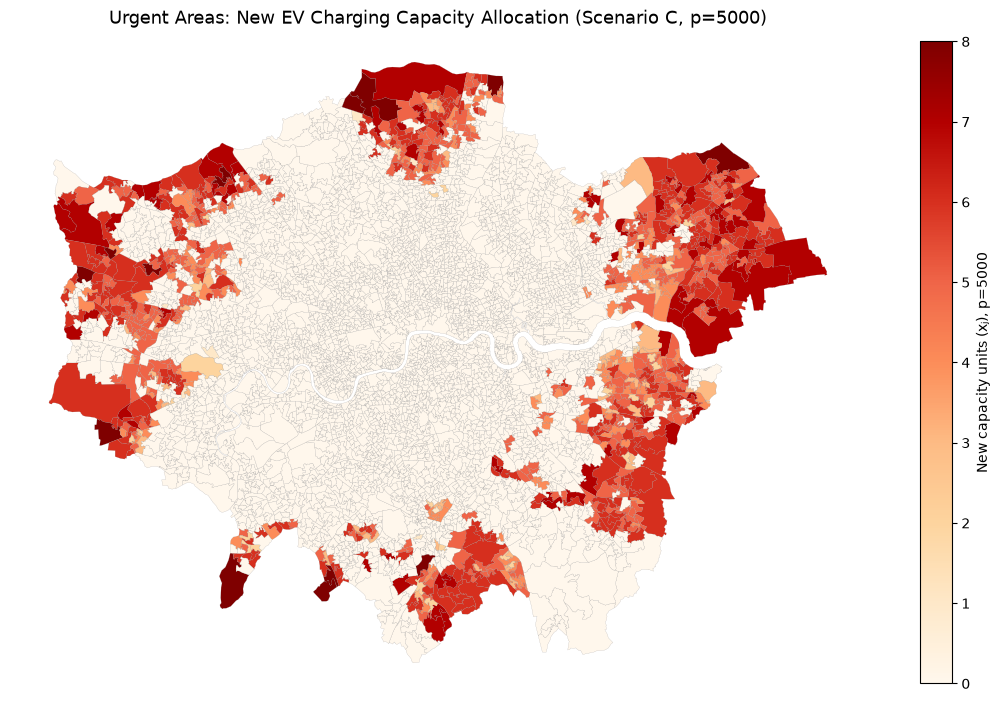

In [2]:
PRIMARY_P = 5000
PRIMARY_SCENARIO = "C"
xj_col = f"xj_{PRIMARY_SCENARIO}_p{PRIMARY_P}"

map_data = lsoa_london.merge(results_wide[["lsoa_code", xj_col]], on="lsoa_code", how="left")

n_zero = (results_wide[xj_col] == 0).sum()
n_positive = (results_wide[xj_col] > 0).sum()
print(f"p={PRIMARY_P}, Scenario {PRIMARY_SCENARIO}: {n_zero:,} LSOAs need 0 new units, "
      f"{n_positive:,} LSOAs are allocated >0 (the 'urgent areas'), max xj = {results_wide[xj_col].max()}")

fig, ax = plt.subplots(figsize=(11, 11))
map_data.plot(column=xj_col, cmap="OrRd", linewidth=0.1, edgecolor="grey",
              legend=True, ax=ax, legend_kwds={"label": f"New capacity units (xⱼ), p={PRIMARY_P}", "shrink": 0.6})
ax.set_title(f"Urgent Areas: New EV Charging Capacity Allocation (Scenario {PRIMARY_SCENARIO}, p={PRIMARY_P})", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, f"fig_xj_urgent_areas_{PRIMARY_SCENARIO}_p{PRIMARY_P}.png"), dpi=300, bbox_inches="tight")
plt.show()


## Same map across all three tested p values (Scenario C)

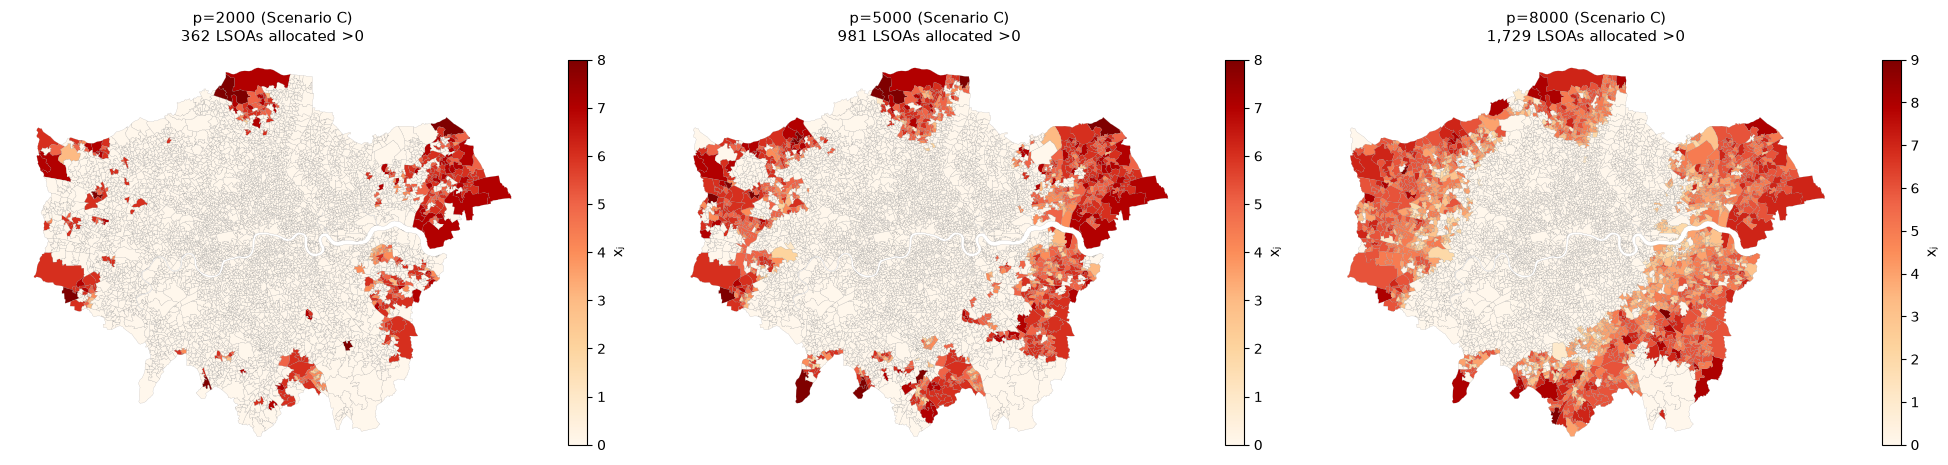

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, p in zip(axes, [2000, 5000, 8000]):
    col = f"xj_{PRIMARY_SCENARIO}_p{p}"
    md_p = lsoa_london.merge(results_wide[["lsoa_code", col]], on="lsoa_code", how="left")
    md_p.plot(column=col, cmap="OrRd", linewidth=0.1, edgecolor="grey",
              legend=True, ax=ax, legend_kwds={"label": "xⱼ", "shrink": 0.5})
    n_pos = (results_wide[col] > 0).sum()
    ax.set_title(f"p={p} (Scenario {PRIMARY_SCENARIO})\n{n_pos:,} LSOAs allocated >0", fontsize=11)
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, f"fig_xj_urgent_areas_{PRIMARY_SCENARIO}_all_p.png"), dpi=300, bbox_inches="tight")
plt.show()


## Comparison — Scenario A (efficiency) vs Scenario D (equity), p=5000

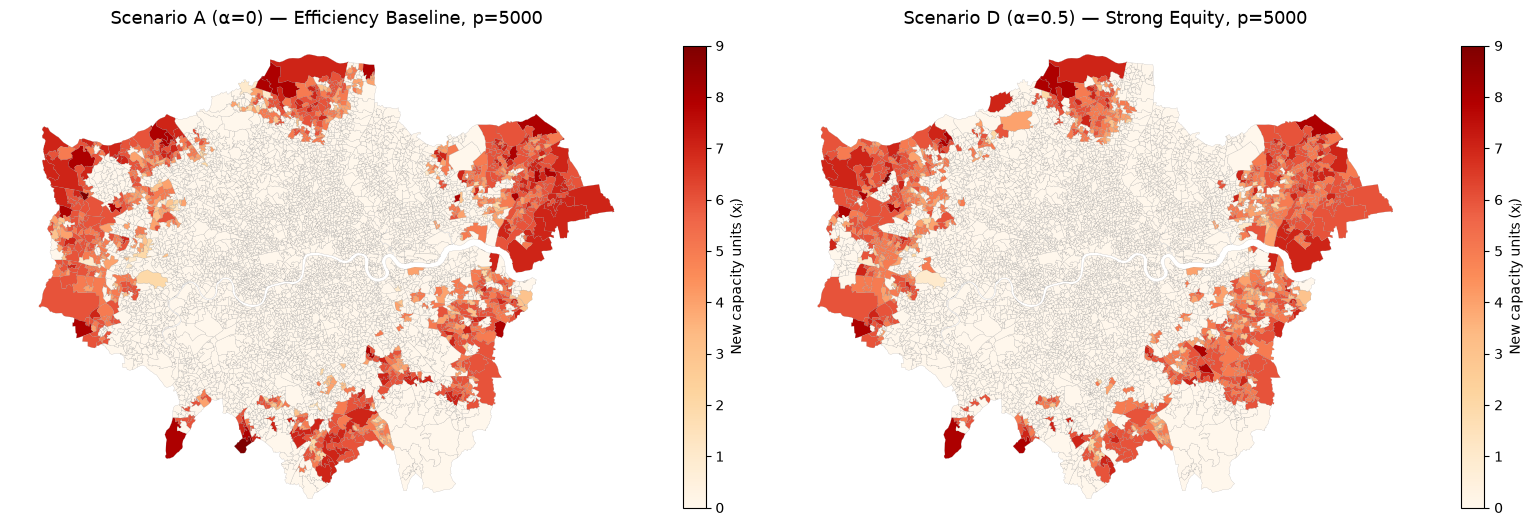

In [4]:
map_data_ad = lsoa_london.merge(
    results_wide[["lsoa_code", f"xj_A_p{PRIMARY_P}", f"xj_D_p{PRIMARY_P}"]], on="lsoa_code", how="left"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
map_data_ad.plot(column=f"xj_A_p{PRIMARY_P}", cmap="OrRd", linewidth=0.1, edgecolor="grey",
              legend=True, ax=axes[0], legend_kwds={"label": "New capacity units (xⱼ)", "shrink": 0.6})
axes[0].set_title(f"Scenario A (α=0) — Efficiency Baseline, p={PRIMARY_P}", fontsize=13)
axes[0].axis("off")

map_data_ad.plot(column=f"xj_D_p{PRIMARY_P}", cmap="OrRd", linewidth=0.1, edgecolor="grey",
              legend=True, ax=axes[1], legend_kwds={"label": "New capacity units (xⱼ)", "shrink": 0.6})
axes[1].set_title(f"Scenario D (α=0.5) — Strong Equity, p={PRIMARY_P}", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_allocation_A_vs_D_final.png"), dpi=300, bbox_inches="tight")
plt.show()
